<a href="https://colab.research.google.com/github/jethrocsau/mimic-multimodal-discordance/blob/main/modality_eda/labs/labs_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Labs modality EDA (aligned with the ECG and CXR notebooks)

**Same as ECG / CXR:** cohort tables (`ace-apex-508114-n9.phase0`), levels L1/L2/L3, `has_all5` filter, 1-year mortality, 80/10/10 split (`random_state=88`), the same models and metrics, and the same repeated cross-validation.

**Different:** labs are already numbers, so there is no pretrained embedding. Each patient gets interpretable **Tier 0** features: for a fixed panel of 22 labs, the first, last, min and max value in the window and the number of measurements. Missing labs are imputed with the training median plus a missingness indicator.

Before running: (1) check the panel itemids in the *Check the lab panel* cell; (2) confirm with Jethro that the window below matches the manifest's `baseline` phase.

**Before pushing to GitHub: Edit → Clear all outputs** (the repo is public).

## Setup

In [3]:
!pip -q install umap-learn

import os, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from google.colab import auth, drive
from google.cloud import bigquery
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- settings ----
PROJECT   = "YOUR_GCP_PROJECT"       # your GCP project: runs the queries
DATA_PROJ = "ace-apex-508114-n9"      # Jethro's project: cohort tables (read only)
OUT_DIR   = "/content/drive/MyDrive/capstone_labs"
WIN_BEFORE_H, WIN_AFTER_H = 72, 24    # feature window around ICU admission; must match the 'baseline' phase

# Lab panel: itemid -> short name (MIMIC-IV hosp.labevents). Verified in the next section.
PANEL = {
    50983: "sodium", 50971: "potassium", 50902: "chloride", 50882: "bicarbonate", 50868: "anion_gap",
    51006: "bun", 50912: "creatinine", 50931: "glucose", 50893: "calcium", 50960: "magnesium",
    50970: "phosphate", 51222: "hemoglobin", 51301: "wbc", 51265: "platelets",
    51003: "troponin_t", 50963: "ntprobnp", 50862: "albumin", 50885: "bilirubin",
    50861: "alt", 50878: "ast", 51237: "inr", 50813: "lactate",
}
STATS = ["first", "last", "min", "max", "n"]

if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")
auth.authenticate_user()
client = bigquery.Client(project=PROJECT)
os.makedirs(OUT_DIR, exist_ok=True)

## Check the lab panel
Every row should be the lab named in `PANEL` (fluid = Blood). Fix any itemid that is wrong before going on.

In [4]:
ids = ", ".join(str(i) for i in PANEL)
check = client.query(f"""
    SELECT itemid, label, fluid, category
    FROM `physionet-data.mimiciv_3_1_hosp.d_labitems`
    WHERE itemid IN ({ids})
""").to_dataframe()
check["panel_name"] = check["itemid"].map(PANEL)
check.sort_values("panel_name")

,itemid,label,fluid,category,panel_name
2,50862,Albumin,Blood,Chemistry,albumin
1,50861,Alanine Aminotransferase (ALT),Blood,Chemistry,alt
3,50868,Anion Gap,Blood,Chemistry,anion_gap
4,50878,Asparate Aminotransferase (AST),Blood,Chemistry,ast
5,50882,Bicarbonate,Blood,Chemistry,bicarbonate
6,50885,"Bilirubin, Total",Blood,Chemistry,bilirubin
17,51006,Urea Nitrogen,Blood,Chemistry,bun
7,50893,"Calcium, Total",Blood,Chemistry,calcium
8,50902,Chloride,Blood,Chemistry,chloride
9,50912,Creatinine,Blood,Chemistry,creatinine


## Helper Functions

In [5]:
def fetch_cohort(bq_client):
    """One row per (cohort level, stay): label, demographics and ICU admission time. Same cohort as ECG/CXR."""
    query = f"""
        SELECT DISTINCT
          a.level_id, a.stay_id, a.subject_id, a.hadm_id, a.died_1y, a.age, a.sex, icu.intime,
          CASE
            WHEN adm.race LIKE 'WHITE%' THEN 'White'
            WHEN adm.race LIKE 'BLACK%' THEN 'Black'
            WHEN adm.race LIKE 'HISPANIC%' OR adm.race LIKE 'SOUTH AMERICAN%' THEN 'Hispanic/Latino'
            WHEN adm.race LIKE 'ASIAN%' THEN 'Asian'
            WHEN adm.race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') OR adm.race IS NULL THEN 'Unknown'
            ELSE 'Other'
          END AS race_group,
          CASE
            WHEN a.age < 65 THEN '18-64'
            WHEN a.age < 75 THEN '65-74'
            WHEN a.age < 85 THEN '75-84'
            ELSE '>=85'
          END AS age_group
        FROM `{DATA_PROJ}.phase0.analysis_dataset` a
        JOIN `physionet-data.mimiciv_3_1_icu.icustays` icu ON icu.stay_id = a.stay_id
        LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` adm ON adm.hadm_id = a.hadm_id
        WHERE a.has_all5 AND a.level_id IN ('L1', 'L2', 'L3')
    """
    df = bq_client.query(query).to_dataframe()
    print(f"Cohort: {df.groupby('level_id').stay_id.nunique().to_dict()} stays per level")
    return df


def fetch_lab_features(bq_client):
    """
    Long table: one row per (stay, lab) with first/last/min/max value and count inside the window.
    Labs are joined on subject_id so ED labs drawn before the hospital admission are included.
    """
    ids = ", ".join(str(i) for i in PANEL)
    query = f"""
        WITH stays AS (
          SELECT DISTINCT a.stay_id, a.subject_id, icu.intime
          FROM `{DATA_PROJ}.phase0.analysis_dataset` a
          JOIN `physionet-data.mimiciv_3_1_icu.icustays` icu ON icu.stay_id = a.stay_id
          WHERE a.has_all5 AND a.level_id IN ('L1', 'L2', 'L3')
        ),
        vals AS (
          SELECT s.stay_id, le.itemid, le.charttime, le.valuenum
          FROM stays s
          JOIN `physionet-data.mimiciv_3_1_hosp.labevents` le ON le.subject_id = s.subject_id
          WHERE le.itemid IN ({ids})
            AND le.valuenum IS NOT NULL
            AND le.charttime >= DATETIME_SUB(s.intime, INTERVAL {WIN_BEFORE_H} HOUR)
            AND le.charttime <  DATETIME_ADD(s.intime, INTERVAL {WIN_AFTER_H} HOUR)
        )
        SELECT stay_id, itemid,
               ARRAY_AGG(valuenum ORDER BY charttime ASC  LIMIT 1)[OFFSET(0)] AS first,
               ARRAY_AGG(valuenum ORDER BY charttime DESC LIMIT 1)[OFFSET(0)] AS last,
               MIN(valuenum) AS min, MAX(valuenum) AS max, COUNT(*) AS n
        FROM vals
        GROUP BY stay_id, itemid
    """
    long = bq_client.query(query).to_dataframe()
    long["lab"] = long["itemid"].map(PANEL)
    print(f"Lab rows: {len(long):,} (stay x lab), {long.stay_id.nunique():,} stays with any panel lab")
    return long


def to_wide(long):
    """One row per stay; columns lab_<name>_<stat>. A lab never measured gives NaN values and n = 0."""
    wide = long.pivot_table(index="stay_id", columns="lab", values=STATS, aggfunc="first")
    wide.columns = [f"lab_{lab}_{stat}" for stat, lab in wide.columns]
    for lab in PANEL.values():                                   # make sure every column exists
        for stat in STATS:
            col = f"lab_{lab}_{stat}"
            if col not in wide.columns:
                wide[col] = np.nan
    wide = wide[[f"lab_{lab}_{stat}" for lab in PANEL.values() for stat in STATS]]
    n_cols = [c for c in wide.columns if c.endswith("_n")]
    wide[n_cols] = wide[n_cols].fillna(0)
    return wide.reset_index()

## Load data

In [6]:
cohort_df = fetch_cohort(client)
lab_long = fetch_lab_features(client)
lab_wide = to_wide(lab_long)

final_data_df = cohort_df.merge(lab_wide, on="stay_id", how="left")
n_cols = [c for c in final_data_df.columns if c.startswith("lab_") and c.endswith("_n")]
final_data_df[n_cols] = final_data_df[n_cols].fillna(0)                   # stays with no panel lab at all
final_data_df["outcome"] = final_data_df["died_1y"].map({True: "Died", False: "Survived"})

embedding_cols = [c for c in final_data_df.columns if c.startswith("lab_")]       # all lab features
value_cols     = [c for c in embedding_cols if not c.endswith("_n")]              # values only (no counts)
print(f"final_data_df: {final_data_df.shape[0]:,} rows = one per (level, stay); "
      f"{len(embedding_cols)} lab features ({len(value_cols)} values + {len(embedding_cols) - len(value_cols)} counts)")
final_data_df.groupby("level_id").stay_id.nunique()

Cohort: {'L1': 997, 'L2': 1489, 'L3': 2323} stays per level
Lab rows: 45,652 (stay x lab), 2,421 stays with any panel lab
final_data_df: 4,809 rows = one per (level, stay); 110 lab features (88 values + 22 counts)


,stay_id
level_id,
L1,997
L2,1489
L3,2323


**Check:** stays per level should match ECG/CXR (L1 997, L2 1,489, L3 2,323).

## Lab availability (missingness)
Share of patients with at least one value of each lab in the window, per level.

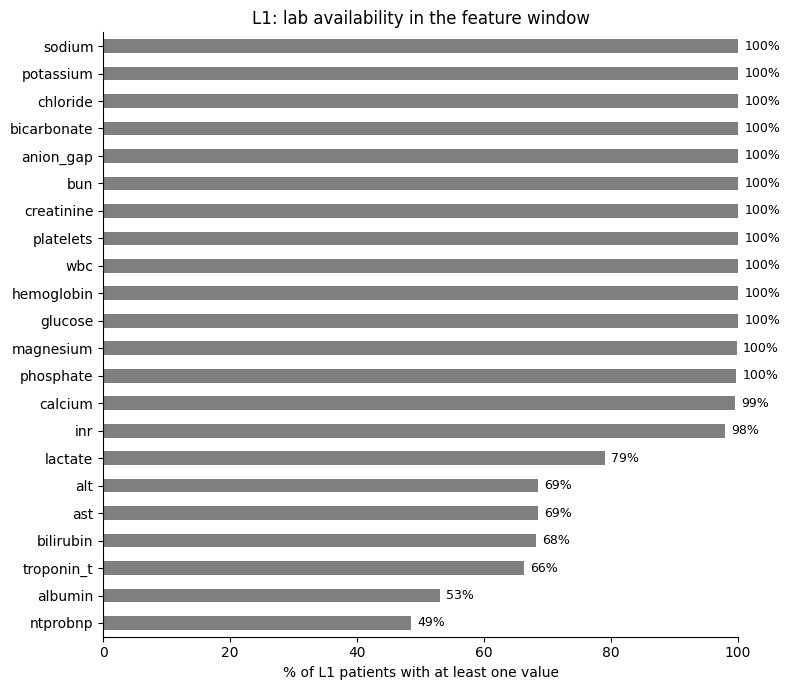

level_id,L1,L2,L3
ntprobnp,48.545637,38.415044,28.067155
albumin,53.059178,51.6454,51.485149
troponin_t,66.298897,62.055071,48.773138
bilirubin,68.204614,65.34587,62.290142
ast,68.505517,65.681666,62.634524
alt,68.505517,65.681666,62.763668
lactate,79.037111,74.680994,81.74774
inr,97.993982,96.977837,97.67542
calcium,99.498495,99.328408,94.532932
phosphate,99.699097,99.462727,94.532932


In [7]:
avail = (final_data_df.groupby("level_id")[[f"lab_{lab}_n" for lab in PANEL.values()]]
                      .agg(lambda s: (s > 0).mean() * 100).T)
avail.index = [i.replace("lab_", "").replace("_n", "") for i in avail.index]
avail = avail.sort_values("L1")

fig, ax = plt.subplots(figsize=(8, 7))
avail["L1"].plot.barh(ax=ax, color="#7f7f7f")
ax.set(xlabel="% of L1 patients with at least one value", ylabel="", xlim=(0, 100),
       title="L1: lab availability in the feature window")
for i, v in enumerate(avail["L1"]):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/labs_availability_L1.png", dpi=150); plt.show()
avail.round(1)

Labs measured in nearly everyone (sodium, creatinine, haemoglobin) carry little missingness. Labs measured in a minority (lactate, troponin, NT-proBNP, liver tests) are ordered selectively, so *whether* they were ordered is itself informative about how worried the clinicians were.

## Exploring Demographics
Same cohort as ECG/CXR, so these plots should match those notebooks.

In [8]:
dem_patient_df = final_data_df
print("=== Patient Counts per Cohort ===")
for lvl in ['L1', 'L2', 'L3']:
    d = dem_patient_df[dem_patient_df['level_id'] == lvl]
    print(f"Cohort {lvl}: {d['subject_id'].nunique():,} patients, "
          f"{d['died_1y'].sum():,} died within 1y ({100 * d['died_1y'].mean():.1f}%)")

=== Patient Counts per Cohort ===
Cohort L1: 997 patients, 355 died within 1y (35.6%)
Cohort L2: 1,489 patients, 491 died within 1y (33.0%)
Cohort L3: 2,323 patients, 585 died within 1y (25.2%)


## Which single labs separate outcomes?
AUROC of each lab's first value on its own (L1, patients with that lab measured). Values below 0.5 mean *lower* values go with death; the bar shows the distance from 0.5 in either direction.

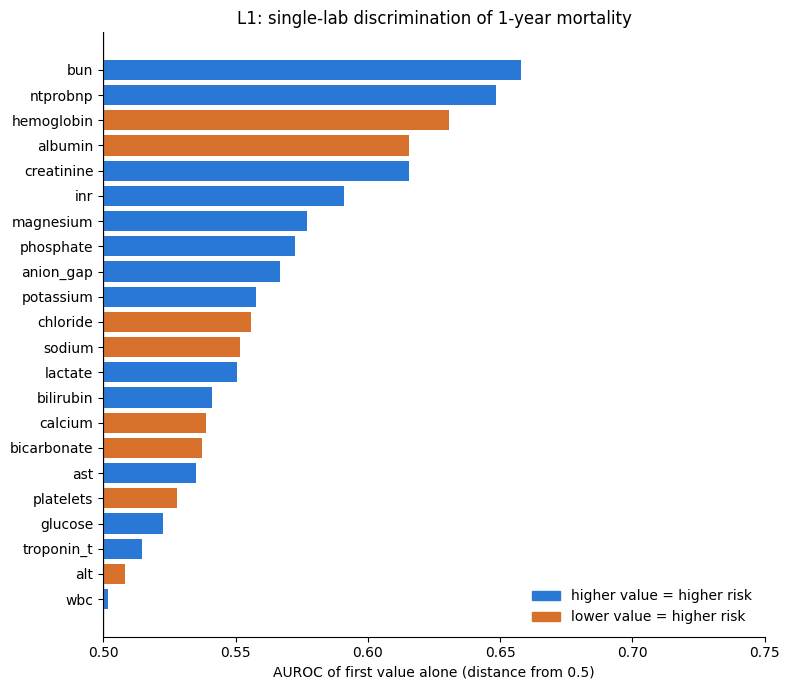

,lab,auroc,strength,direction,n
5,bun,0.658,0.658,higher = worse,997
15,ntprobnp,0.648,0.648,higher = worse,484
11,hemoglobin,0.369,0.631,lower = worse,997
16,albumin,0.384,0.616,lower = worse,529
6,creatinine,0.615,0.615,higher = worse,997
20,inr,0.591,0.591,higher = worse,977
9,magnesium,0.577,0.577,higher = worse,995
10,phosphate,0.573,0.573,higher = worse,994
4,anion_gap,0.567,0.567,higher = worse,997
1,potassium,0.558,0.558,higher = worse,997


In [9]:
from sklearn.metrics import roc_auc_score
d = final_data_df[final_data_df.level_id == "L1"]
rows = []
for lab in PANEL.values():
    m = d[f"lab_{lab}_first"].notna()
    if m.sum() < 50 or d.loc[m, "died_1y"].nunique() < 2:
        continue
    auc = roc_auc_score(d.loc[m, "died_1y"].astype(int), d.loc[m, f"lab_{lab}_first"])
    rows.append({"lab": lab, "auroc": auc, "strength": abs(auc - 0.5) + 0.5,
                 "direction": "higher = worse" if auc >= 0.5 else "lower = worse", "n": int(m.sum())})
uni = pd.DataFrame(rows).sort_values("strength")

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#2a78d6" if r == "higher = worse" else "#d6702a" for r in uni.direction]
ax.barh(uni.lab, uni.strength - 0.5, left=0.5, color=colors)
ax.axvline(0.5, color="grey", lw=1)
ax.set(xlabel="AUROC of first value alone (distance from 0.5)", xlim=(0.5, 0.75),
       title="L1: single-lab discrimination of 1-year mortality")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2a78d6", label="higher value = higher risk"),
                   Patch(color="#d6702a", label="lower value = higher risk")], loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/labs_univariate_L1.png", dpi=150); plt.show()
uni.sort_values("strength", ascending=False).round(3)

## Embedding Visualization
UMAP of the lab feature vector (median-imputed, standardised, with missingness indicators), coloured exactly as in the ECG/CXR notebooks.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


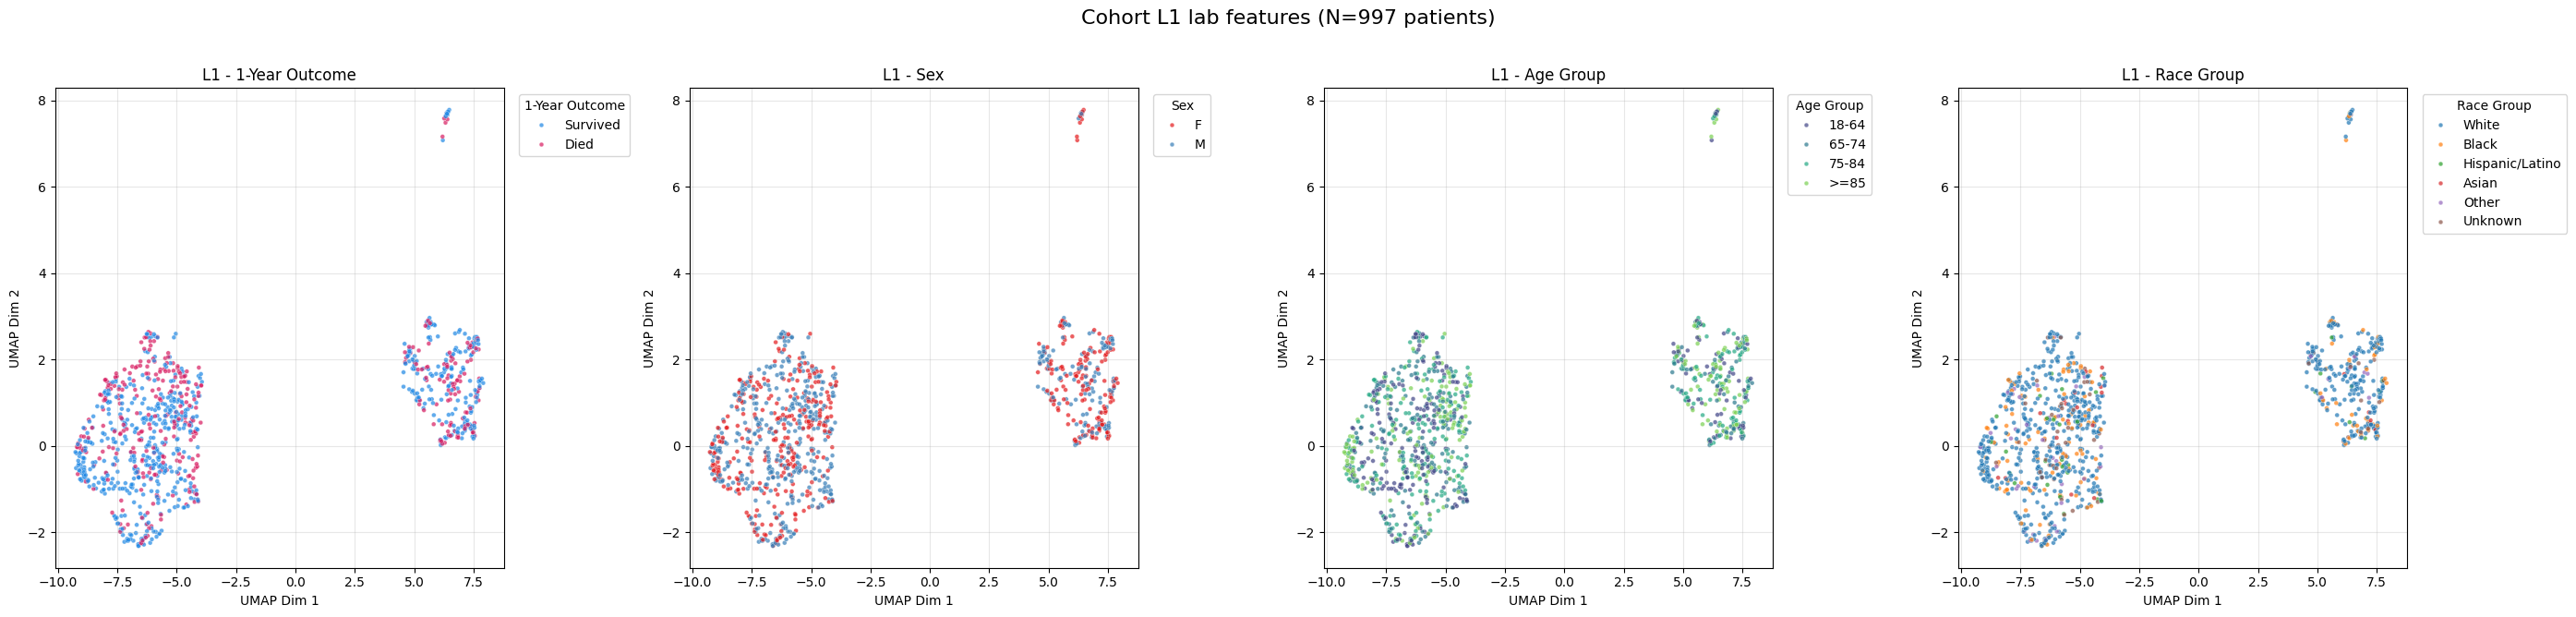

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


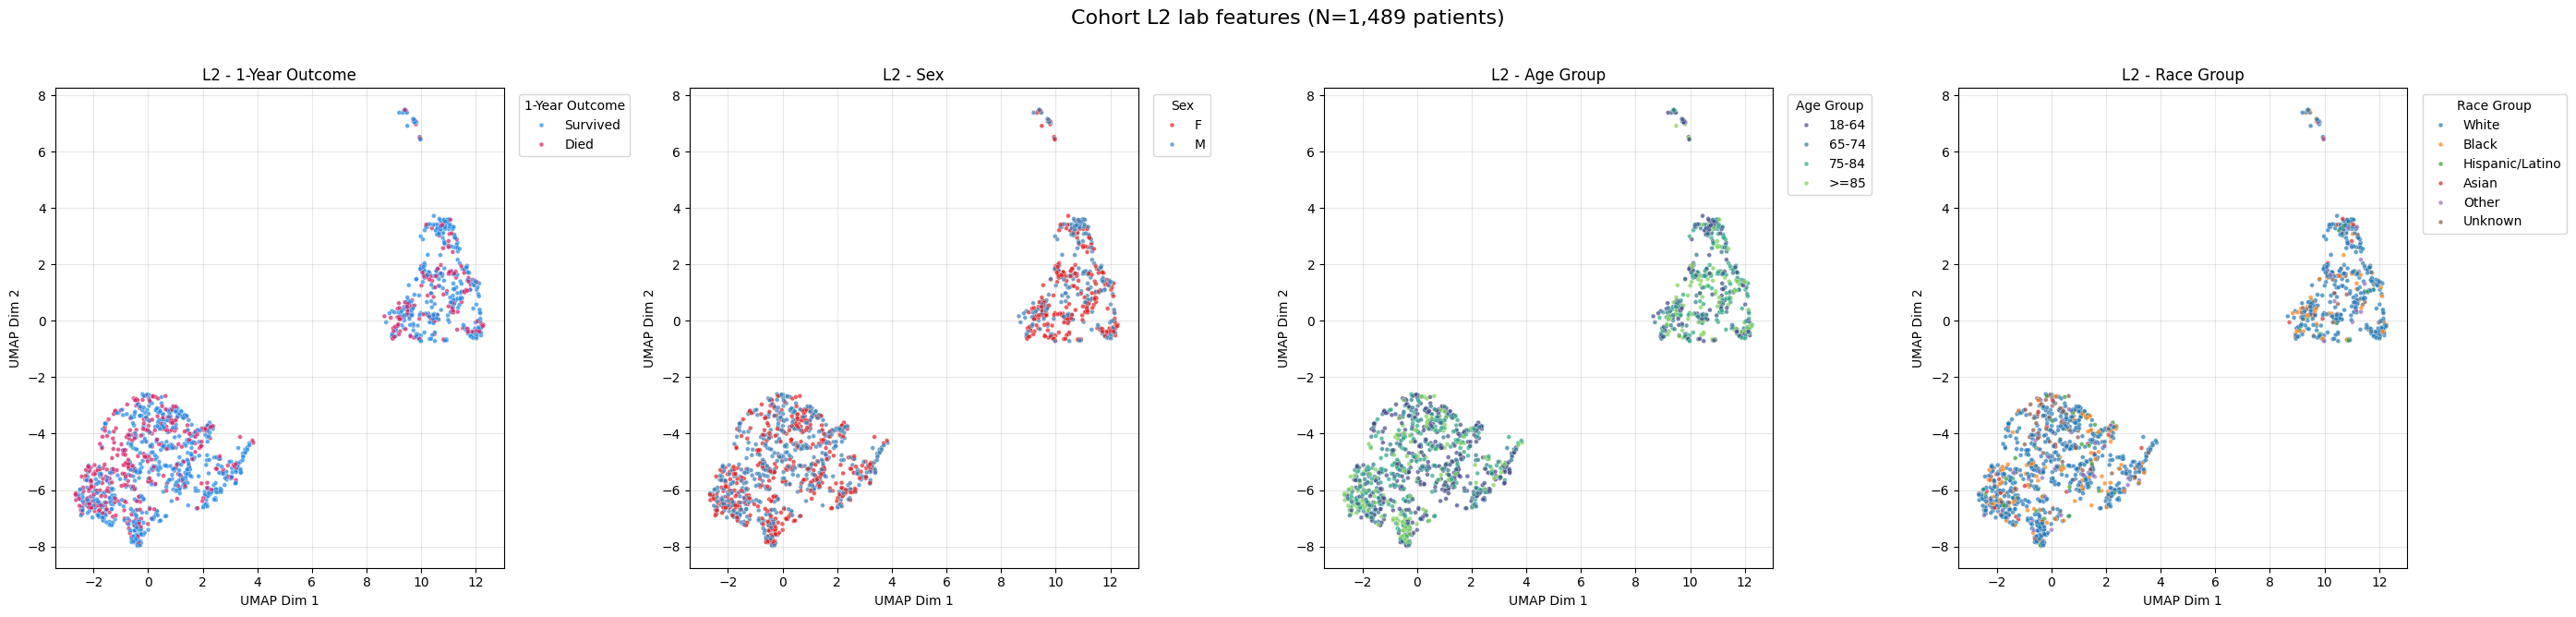

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


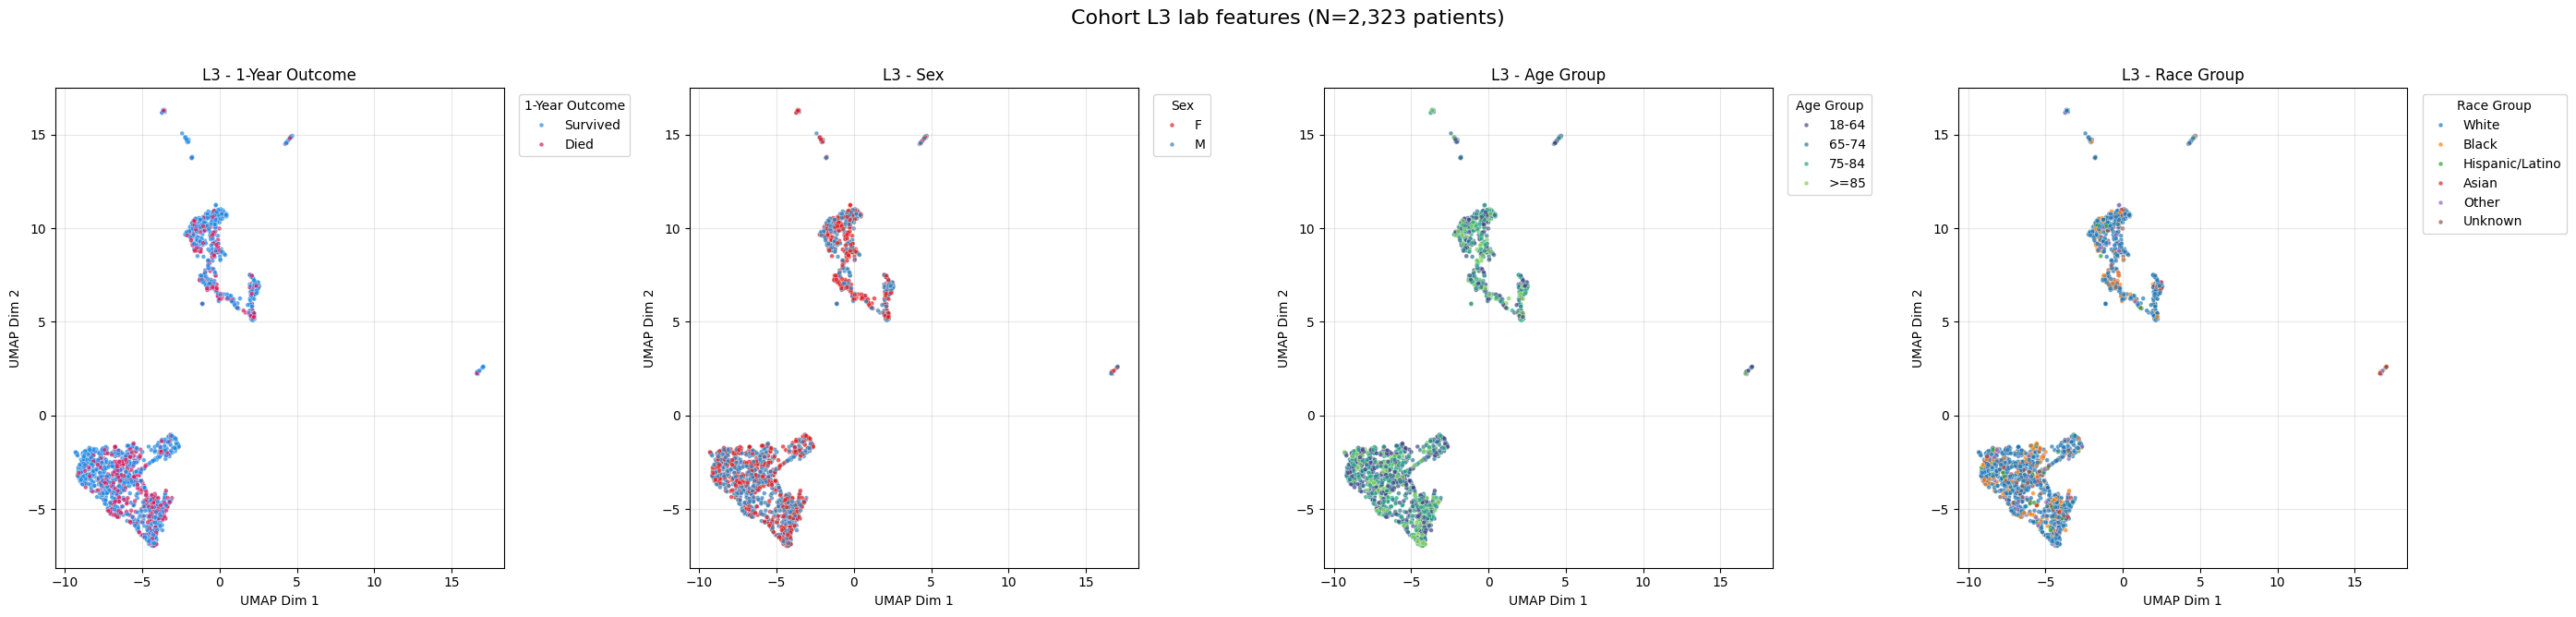

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def lab_matrix(df, cols):
    """Median-impute + missingness indicators + standardise (EDA only; models fit these on train data)."""
    X = SimpleImputer(strategy="median", add_indicator=True).fit_transform(df[cols])
    return StandardScaler().fit_transform(X)

orders = {'outcome': ['Survived', 'Died'], 'sex': ['F', 'M'],
          'age_group': ['18-64', '65-74', '75-84', '>=85'],
          'race_group': ['White', 'Black', 'Hispanic/Latino', 'Asian', 'Other', 'Unknown']}
color_vars = [('outcome', '1-Year Outcome', {'Survived': '#1E88E5', 'Died': '#D81B60'}),
              ('sex', 'Sex', 'Set1'), ('age_group', 'Age Group', 'viridis'), ('race_group', 'Race Group', 'tab10')]

for level in ['L1', 'L2', 'L3']:
    sub = final_data_df[final_data_df.level_id == level].copy()
    xy = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=88).fit_transform(lab_matrix(sub, embedding_cols))
    sub['umap_x'], sub['umap_y'] = xy[:, 0], xy[:, 1]
    fig, axes = plt.subplots(1, 4, figsize=(28, 6.5))
    for ax, (var, title, pal) in zip(axes, color_vars):
        sns.scatterplot(data=sub, x='umap_x', y='umap_y', hue=var,
                        hue_order=[v for v in orders[var] if v in set(sub[var])], ax=ax, alpha=0.7, s=12, palette=pal)
        ax.set(title=f"{level} - {title}", xlabel="UMAP Dim 1", ylabel="UMAP Dim 2")
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left'); ax.grid(True, alpha=0.3)
    plt.suptitle(f"Cohort {level} lab features (N={len(sub):,} patients)", fontsize=16, y=1.02)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/labs_umap_{level}.png", dpi=150, bbox_inches="tight"); plt.show()

## Unimodal probe
Same models as ECG/CXR. The only change: labs have missing values, so the split function fits a median imputer (with missingness indicators) on the training split before scaling.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_curve, average_precision_score, f1_score, confusion_matrix

def split_cohort_data(df, feature_cols, target_col='died_1y', test_size=0.1, val_size=0.1, random_state=88):
    """Stratified 80/10/10 patient-level split. Imputer and scalers are fit on the training split only."""
    model_df = df.dropna(subset=['age', 'sex']).copy()
    assert model_df['subject_id'].is_unique, "filter to one level_id first (one row per patient)"
    X = model_df[feature_cols].values.astype(float)
    D = np.column_stack([model_df['age'].astype(float).values, (model_df['sex'] == 'M').astype(int).values])
    y = model_df[target_col].astype(int).values

    idx = np.arange(len(y))
    idx_tv, idx_te = train_test_split(idx, test_size=test_size, stratify=y, random_state=random_state)
    idx_tr, idx_va = train_test_split(idx_tv, test_size=val_size / (1 - test_size),
                                      stratify=y[idx_tv], random_state=random_state)

    imp = SimpleImputer(strategy="median", add_indicator=True).fit(X[idx_tr])
    Xi = imp.transform(X)
    xs = StandardScaler().fit(Xi[idx_tr]); ds = StandardScaler().fit(D[idx_tr])
    Xs, Ds = xs.transform(Xi), ds.transform(D)
    print(f"N={len(y):,} ({y.sum():,} died, {100 * y.mean():.1f}%) | train {len(idx_tr):,} / val {len(idx_va):,} / "
          f"test {len(idx_te):,} ({y[idx_te].sum()} deaths in test) | {Xs.shape[1]} features after imputation")
    return (Xs[idx_tr], Xs[idx_va], Xs[idx_te], Ds[idx_tr], Ds[idx_va], Ds[idx_te],
            y[idx_tr], y[idx_va], y[idx_te])


def train_logistic_classifier(X_train, y_train, X_val=None, y_val=None, random_state=88):
    c_candidates = [0.001, 0.01, 0.1, 0.5, 1.0, 2.5, 10]
    def fit(c):
        return LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000, C=c,
                                  class_weight='balanced', random_state=random_state).fit(X_train, y_train)
    if X_val is None or y_val is None:
        return fit(1.0)
    best_clf, best_c, best_auc = None, None, -1.0
    for c in c_candidates:
        clf = fit(c); auc = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        if auc > best_auc:
            best_clf, best_c, best_auc = clf, c, auc
    print(f"  LR: best C = {best_c} (val AUROC {best_auc:.4f})")
    return best_clf


class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout_rate),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
    def forward(self, x):
        return self.net(x)


def train_single_nn(X_train, y_train, X_val, y_val, hidden_dim, epochs=50, batch_size=64, lr=0.001, random_state=88):
    torch.manual_seed(random_state)
    model = SimpleNN(X_train.shape[1], hidden_dim)
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).unsqueeze(1)),
                        batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(random_state))
    criterion = nn.BCELoss(); optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    X_val_t, y_val_t = torch.FloatTensor(X_val), torch.FloatTensor(y_val).unsqueeze(1)
    best_val_loss, best_weights = float('inf'), None
    for _ in range(epochs):
        model.train()
        for bx, by in loader:
            optimizer.zero_grad(); loss = criterion(model(bx), by); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        if val_loss < best_val_loss:
            best_val_loss, best_weights = val_loss, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_weights)
    return model, best_val_loss


def train_nn_classifier(X_train, y_train, X_val, y_val, random_state=88):
    d = X_train.shape[1]; best = (None, float('inf'), None)
    for h in [max(d // 2, 1), max(d // 4, 1), max(d // 8, 1), max(d // 16, 1)]:
        model, loss = train_single_nn(X_train, y_train, X_val, y_val, h, random_state=random_state)
        if loss < best[1]:
            best = (model, loss, h)
    print(f"  NN: best hidden size = {best[2]} (val loss {best[1]:.4f})")
    return best[0]


def nn_predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.FloatTensor(X)).numpy().ravel()


def youden_threshold(y_val, p_val):
    fpr, tpr, thr = roc_curve(y_val, p_val)
    return float(thr[np.argmax(tpr - fpr)])


def bootstrap_ci(y_true, y_prob, metric=roc_auc_score, n=1000, seed=88):
    rng = np.random.default_rng(seed); stats = []
    for _ in range(n):
        i = rng.integers(0, len(y_true), len(y_true))
        if y_true[i].min() == y_true[i].max():
            continue
        stats.append(metric(y_true[i], y_prob[i]))
    return np.percentile(stats, [2.5, 97.5])


def evaluate_and_plot(y_true, y_pred_prob, title_suffix, threshold=0.5, plot=True):
    y_pred = (y_pred_prob >= threshold).astype(int)
    auroc = roc_auc_score(y_true, y_pred_prob); lo, hi = bootstrap_ci(y_true, y_pred_prob)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
    metrics = {'AUROC': round(auroc, 4), 'AUROC 95% CI': f"{lo:.3f}-{hi:.3f}",
               'AUPRC': round(average_precision_score(y_true, y_pred_prob), 4),
               'F1': round(f1_score(y_true, y_pred, zero_division=0), 4),
               'PPV (Precision)': round(tp / (tp + fp), 4) if (tp + fp) else 0.0,
               'NPV': round(tn / (tn + fn), 4) if (tn + fn) else 0.0,
               'Sensitivity (Recall)': round(tp / (tp + fn), 4) if (tp + fn) else 0.0,
               'Specificity': round(tn / (tn + fp), 4) if (tn + fp) else 0.0,
               'Threshold': round(threshold, 4)}
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
        axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auroc:.3f} (95% CI {lo:.3f}-{hi:.3f})')
        axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
        axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'ROC Curve - {title_suffix}')
        axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                    xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
        axes[1].set(xlabel='Predicted Label', ylabel='True Label',
                    title=f'Confusion Matrix - {title_suffix} (threshold {threshold:.3f})')
        plt.tight_layout(); plt.show()
    return metrics

## Cohort-by-Cohort Evaluation and Side-by-Side Comparison


PROCESSING COHORT: L1
N=997 (355 died, 35.6%) | train 797 / val 100 / test 100 (36 deaths in test) | 154 features after imputation
  LR: best C = 0.1 (val AUROC 0.7509)


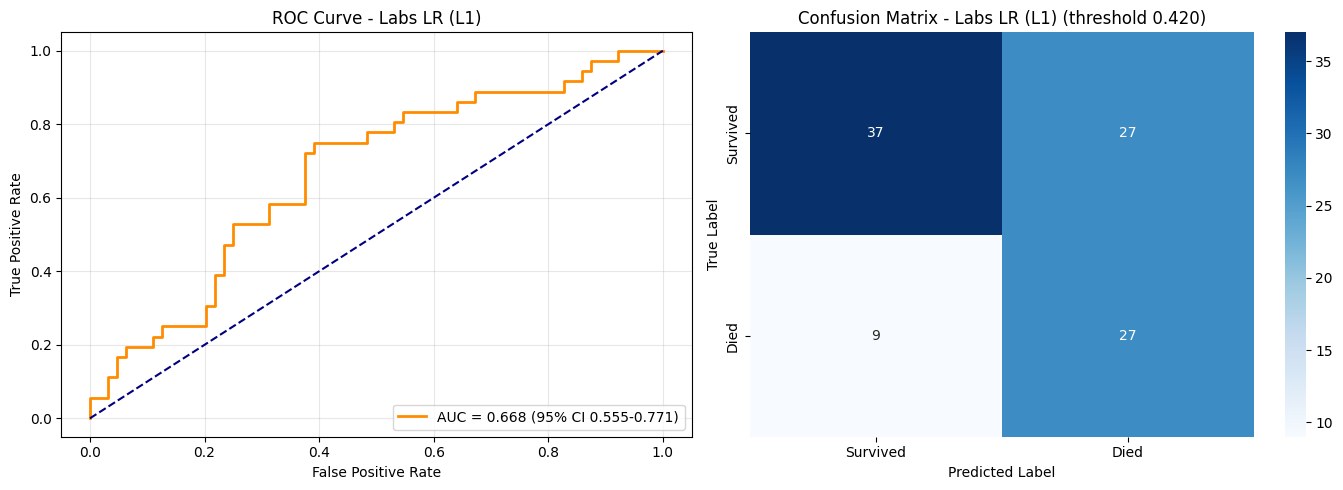

  NN: best hidden size = 38 (val loss 0.5456)


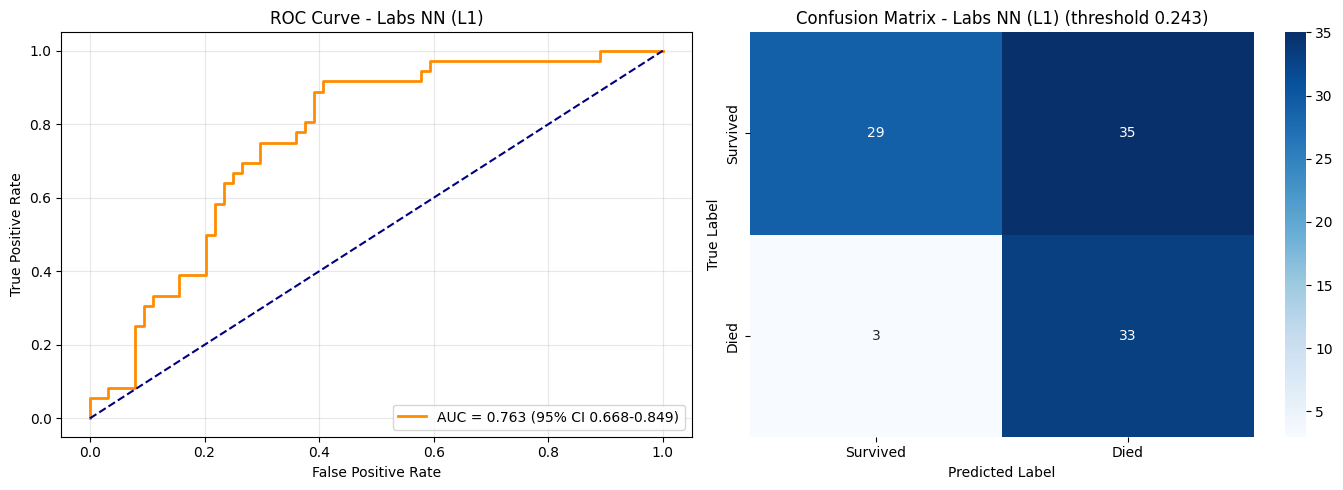

  LR: best C = 0.1 (val AUROC 0.5996)


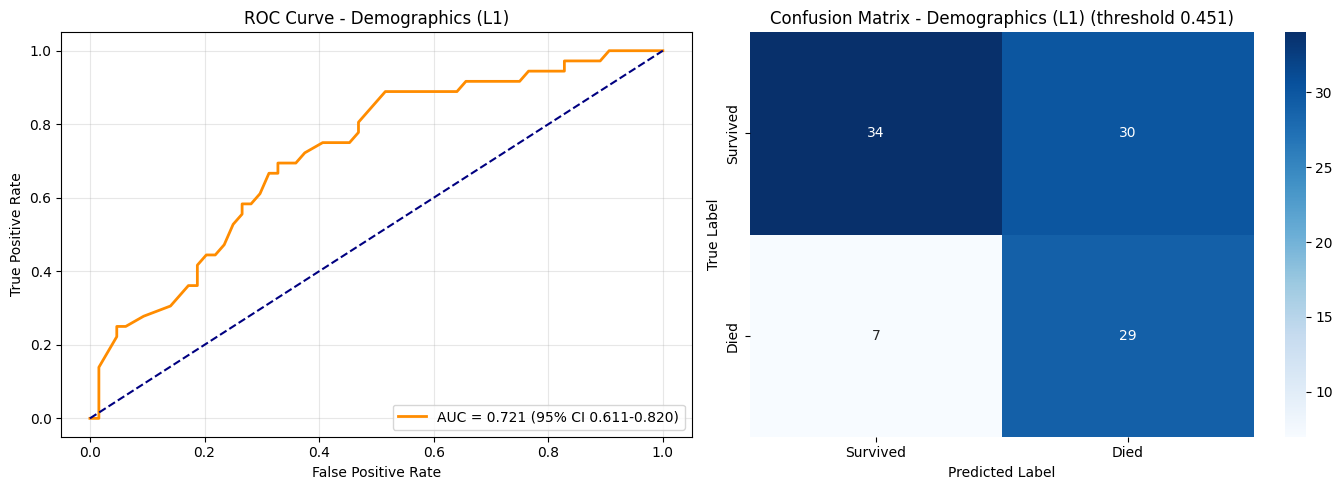


PROCESSING COHORT: L2
N=1,489 (491 died, 33.0%) | train 1,191 / val 149 / test 149 (49 deaths in test) | 154 features after imputation
  LR: best C = 0.01 (val AUROC 0.6945)


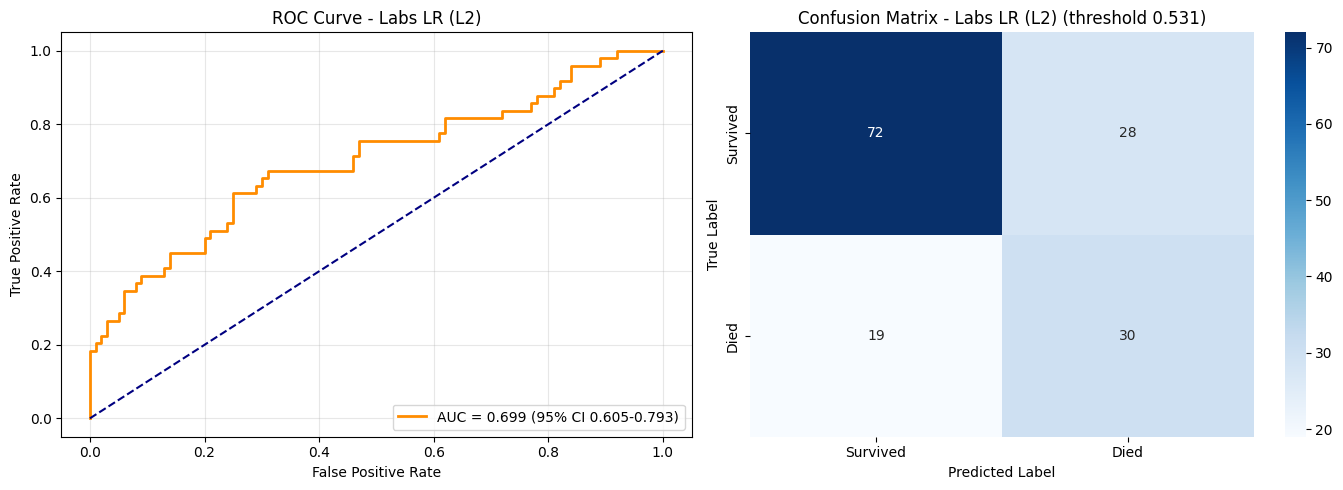

  NN: best hidden size = 77 (val loss 0.5841)


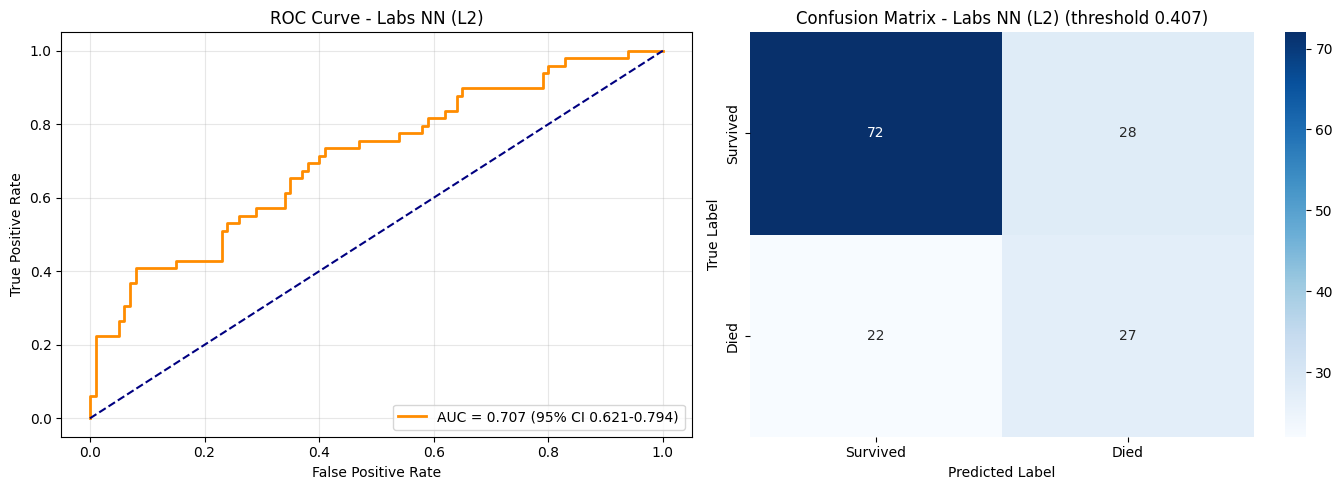

  LR: best C = 0.01 (val AUROC 0.6418)


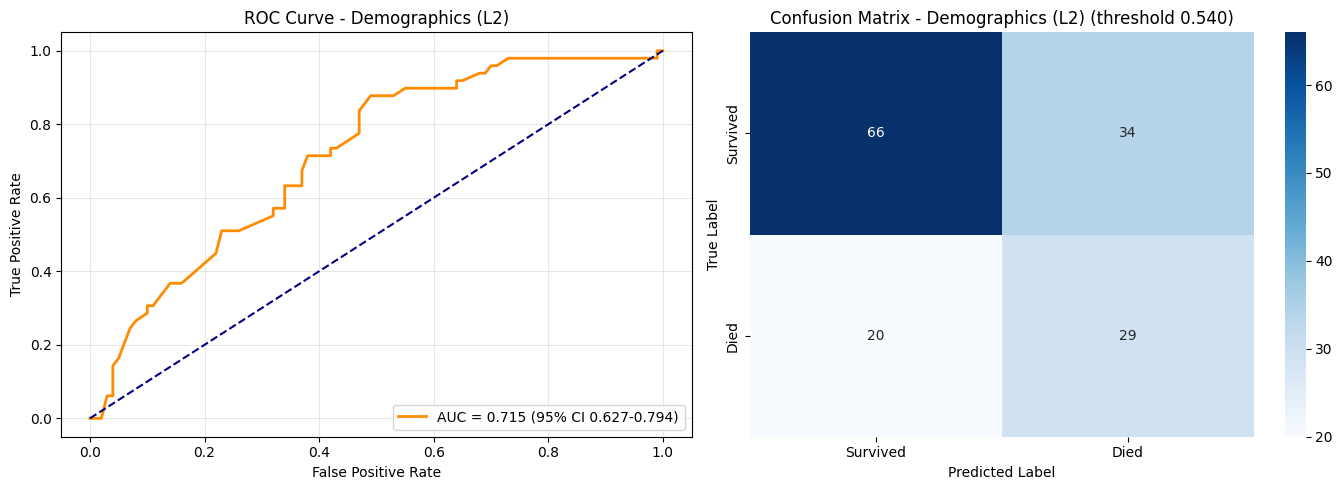


PROCESSING COHORT: L3
N=2,323 (585 died, 25.2%) | train 1,857 / val 233 / test 233 (59 deaths in test) | 154 features after imputation
  LR: best C = 0.5 (val AUROC 0.8087)


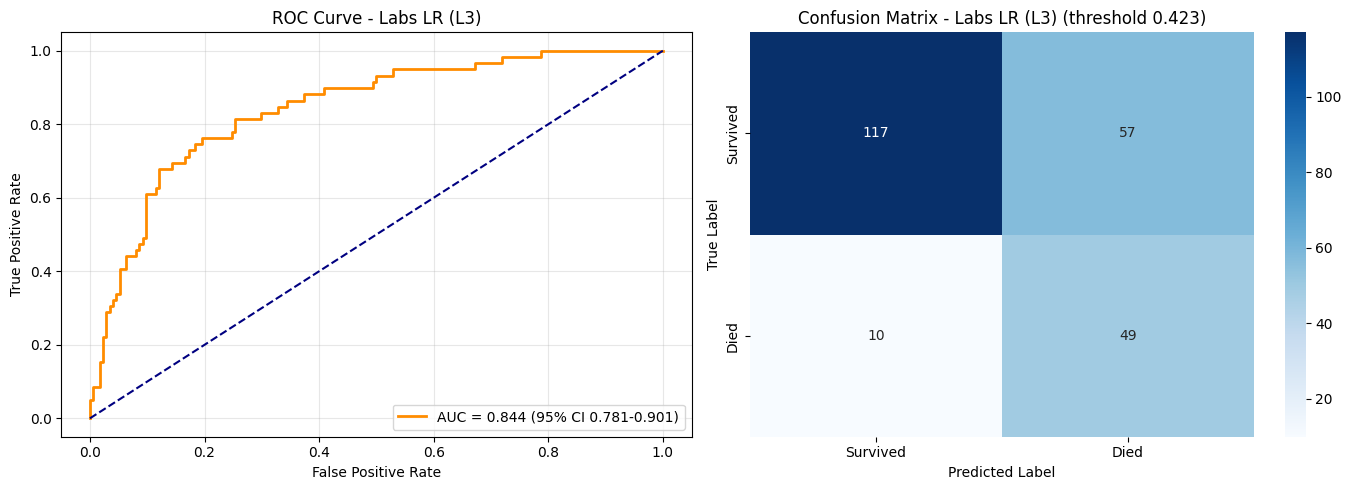

  NN: best hidden size = 19 (val loss 0.4519)


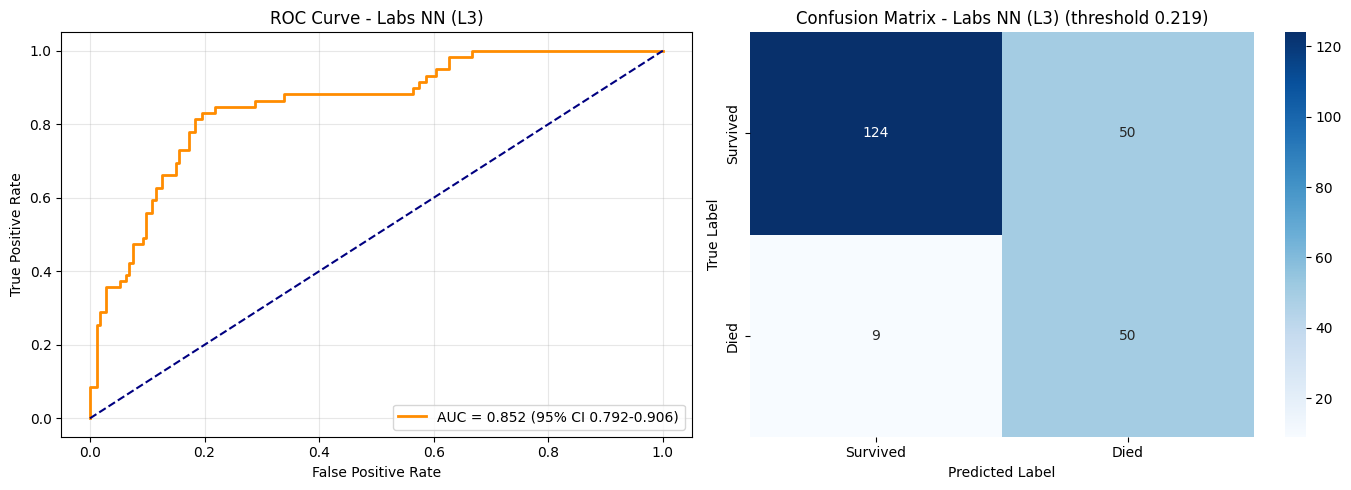

  LR: best C = 0.001 (val AUROC 0.6528)


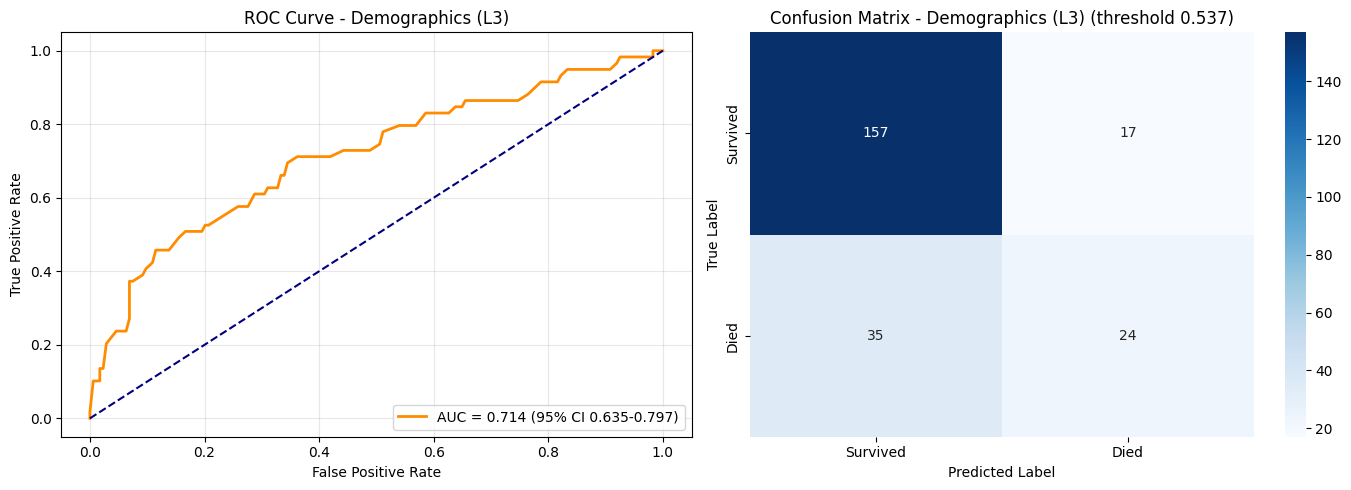

Model                       Labs: Logistic Regression Labs: Neural Network  \
Cohort Metric                                                                
L1     AUPRC                                   0.5285                0.589   
       AUROC                                   0.6675                0.763   
       AUROC 95% CI                       0.555-0.771          0.668-0.849   
       F1                                         0.6               0.6346   
       NPV                                     0.8043               0.9062   
       PPV (Precision)                            0.5               0.4853   
       Sensitivity (Recall)                      0.75               0.9167   
       Specificity                             0.5781               0.4531   
       Threshold                               0.4198               0.2432   
L2     AUPRC                                   0.6199               0.5982   
       AUROC                                    0.699               0.7071   
       AUROC 95% CI                       0.605-0.793          0.621-0.794   
       F1                                      0.5607               0.5192   
       NPV                                     0.7912                0.766   
       PPV (Precision)                         0.5172               0.4909   
       Sensitivity (Recall)                    0.6122                0.551   
       Specificity                               0.72                 0.72   
       Threshold                               0.5308               0.4071   
L3     AUPRC                                   0.6435               0.6784   
       AUROC                                   0.8436               0.8524   
       AUROC 95% CI                       0.781-0.901          0.792-0.906   
       F1                                      0.5939               0.6289   
       NPV                                     0.9213               0.9323   
       PPV (Precision)                         0.4623                  0.5   
       Sensitivity (Recall)                    0.8305               0.8475   
       Specificity                             0.6724               0.7126   
       Threshold                               0.4232               0.2191   

Model                       Demographics (age+sex) Prior (chance)  
Cohort Metric                                                      
L1     AUPRC                                0.5753           0.36  
       AUROC                                0.7207            0.5  
       AUROC 95% CI                    0.611-0.820    0.500-0.500  
       F1                                   0.6105         0.5294  
       NPV                                  0.8293            0.0  
       PPV (Precision)                      0.4915           0.36  
       Sensitivity (Recall)                 0.8056            1.0  
       Specificity                          0.5312            0.0  
       Threshold                            0.4513         0.3551  
L2     AUPRC                                0.5109         0.3289  
       AUROC                                0.7154            0.5  
       AUROC 95% CI                    0.627-0.794    0.500-0.500  
       F1                                   0.5179         0.4949  
       NPV                                  0.7674            0.0  
       PPV (Precision)                      0.4603         0.3289  
       Sensitivity (Recall)                 0.5918            1.0  
       Specificity                            0.66            0.0  
       Threshold                            0.5401           0.33  
L3     AUPRC                                0.5151         0.2532  
       AUROC                                0.7139            0.5  
       AUROC 95% CI                    0.635-0.797    0.500-0.500  
       F1                                     0.48         0.4041  
       NPV                                  0.8177            0.0  
       PPV (Precision)               

In [12]:
metric_names = ['AUROC', 'AUROC 95% CI', 'AUPRC', 'F1', 'PPV (Precision)', 'NPV',
                'Sensitivity (Recall)', 'Specificity', 'Threshold']
results_summary = []
for cohort in ['L1', 'L2', 'L3']:
    print(f"\n{'=' * 50}\nPROCESSING COHORT: {cohort}\n{'=' * 50}")
    cohort_df = final_data_df[final_data_df['level_id'] == cohort]
    (X_train, X_val, X_test, D_train, D_val, D_test,
     y_train, y_val, y_test) = split_cohort_data(cohort_df, embedding_cols, random_state=88)
    m = {}
    lr_model = train_logistic_classifier(X_train, y_train, X_val, y_val)
    t = youden_threshold(y_val, lr_model.predict_proba(X_val)[:, 1])
    m['Labs: Logistic Regression'] = evaluate_and_plot(y_test, lr_model.predict_proba(X_test)[:, 1], f"Labs LR ({cohort})", t)

    nn_model = train_nn_classifier(X_train, y_train, X_val, y_val)
    t = youden_threshold(y_val, nn_predict(nn_model, X_val))
    m['Labs: Neural Network'] = evaluate_and_plot(y_test, nn_predict(nn_model, X_test), f"Labs NN ({cohort})", t)

    demo_model = train_logistic_classifier(D_train, y_train, D_val, y_val)
    t = youden_threshold(y_val, demo_model.predict_proba(D_val)[:, 1])
    m['Demographics (age+sex)'] = evaluate_and_plot(y_test, demo_model.predict_proba(D_test)[:, 1], f"Demographics ({cohort})", t)

    dummy = DummyClassifier(strategy='prior').fit(X_train, y_train)
    m['Prior (chance)'] = evaluate_and_plot(y_test, dummy.predict_proba(X_test)[:, 1], f"Prior ({cohort})",
                                            threshold=y_train.mean(), plot=False)
    for model_name, mm in m.items():
        for k in metric_names:
            results_summary.append({'Cohort': cohort, 'Model': model_name, 'Metric': k, 'Value': mm[k]})

pivot_df = (pd.DataFrame(results_summary).pivot(index=['Cohort', 'Metric'], columns='Model', values='Value')
              .reindex(columns=['Labs: Logistic Regression', 'Labs: Neural Network', 'Demographics (age+sex)', 'Prior (chance)']))
pivot_df.to_csv(f"{OUT_DIR}/labs_split_results.csv")
display(pivot_df)

## Repeated cross-validation (main result)
5-fold CV × 5 seeds; imputation, scaling and the regularisation search all happen inside each training fold. Adds a *values only* model (lab values without measurement counts), because how often a lab is drawn reflects care intensity rather than physiology.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import brier_score_loss
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def cv_auc(X, y, seed, tune=True):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    clf = (LogisticRegressionCV(Cs=np.logspace(-4, 0, 8), cv=3, scoring="roc_auc", max_iter=5000)
           if tune else LogisticRegression(max_iter=5000))
    pipe = make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(), clf)
    p = cross_val_predict(pipe, X, y, cv=skf, method="predict_proba")[:, 1]
    sb = 1 - brier_score_loss(y, p) / brier_score_loss(y, np.full_like(p, y.mean()))
    return roc_auc_score(y, p), sb

cv_rows = []
for lvl in ['L1', 'L2', 'L3']:
    d = final_data_df[final_data_df['level_id'] == lvl].dropna(subset=['age', 'sex'])
    y = d['died_1y'].astype(int).values
    X_l = d[embedding_cols].values.astype(float)
    X_v = d[value_cols].values.astype(float)
    X_d = np.column_stack([d['age'].astype(float).values, (d['sex'] == 'M').astype(int).values])
    for seed in range(5):
        y_shuf = np.random.default_rng(seed).permutation(y)
        for name, X, yy, tune in [("Demographics (age+sex)", X_d, y, False),
                                  ("Labs", X_l, y, True),
                                  ("Labs, values only", X_v, y, True),
                                  ("Labs + demographics", np.hstack([X_l, X_d]), y, True),
                                  ("Labs, shuffled labels", X_l, y_shuf, True)]:
            auc, sb = cv_auc(X, yy, seed, tune)
            cv_rows.append({"level": lvl, "model": name, "seed": seed, "auroc": auc, "scaled_brier": sb})
        print(f"{lvl} seed {seed} done")

cv_summary = (pd.DataFrame(cv_rows).groupby(["level", "model"], sort=False)
                .agg(auroc_mean=("auroc", "mean"), auroc_min=("auroc", "min"), auroc_max=("auroc", "max"),
                     scaled_brier_mean=("scaled_brier", "mean")).round(3))
cv_summary.to_csv(f"{OUT_DIR}/labs_cv_results.csv")
cv_summary

L1 seed 0 done
L1 seed 1 done
L1 seed 2 done
L1 seed 3 done
L1 seed 4 done
L2 seed 0 done
L2 seed 1 done
L2 seed 2 done
L2 seed 3 done
L2 seed 4 done
L3 seed 0 done
L3 seed 1 done
L3 seed 2 done
L3 seed 3 done
L3 seed 4 done


auroc_mean  auroc_min  auroc_max  \
level model                                                      
L1    Demographics (age+sex)       0.649      0.645      0.651   
      Labs                         0.708      0.702      0.714   
      Labs, values only            0.711      0.706      0.718   
      Labs + demographics          0.729      0.726      0.735   
      Labs, shuffled labels        0.506      0.481      0.517   
L2    Demographics (age+sex)       0.642      0.641      0.643   
      Labs                         0.736      0.731      0.740   
      Labs, values only            0.736      0.733      0.739   
      Labs + demographics          0.751      0.749      0.754   
      Labs, shuffled labels        0.497      0.483      0.516   
L3    Demographics (age+sex)       0.660      0.656      0.661   
      Labs                         0.768      0.766      0.770   
      Labs, values only            0.767      0.765      0.768   
      Labs + demographics          0.787      0.783      0.790   
      Labs, shuffled labels        0.518      0.503      0.539   

                              scaled_brier_mean  
level model                                      
L1    Demographics (age+sex)              0.062  
      Labs                                0.113  
      Labs, values only                   0.108  
      Labs + demographics                 0.144  
      Labs, shuffled labels              -0.052  
L2    Demographics (age+sex)              0.053  
      Labs                                0.146  
      Labs, values only                   0.143  
      Labs + demographics                 0.169  
      Labs, shuffled labels              -0.054  
L3    Demographics (age+sex)              0.061  
      Labs                                0.164  
      Labs, values only                   0.163  
      Labs + demographics                 0.195  
      Labs, shuffled labels              -0.023

### Cross-validation plot

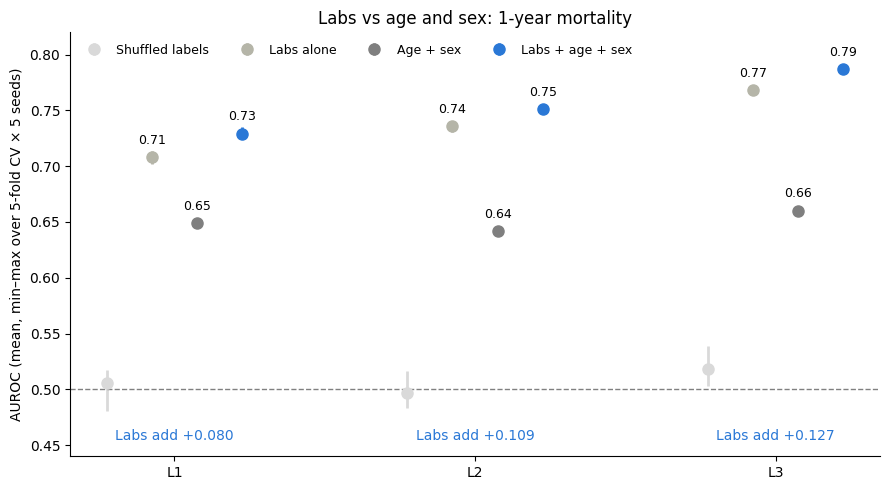

In [14]:
order  = ["Labs, shuffled labels", "Labs", "Demographics (age+sex)", "Labs + demographics"]
labels = ["Shuffled labels", "Labs alone", "Age + sex", "Labs + age + sex"]
colors = ["#d9d9d9", "#b5b5a8", "#7f7f7f", "#2a78d6"]
levels = ["L1", "L2", "L3"]
s = cv_summary.reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for j, (m, lab, c) in enumerate(zip(order, labels, colors)):
    d = s[s["model"] == m].set_index("level").loc[levels]
    x = [i + (j - 1.5) * 0.15 for i in range(len(levels))]
    ax.errorbar(x, d["auroc_mean"], yerr=[d["auroc_mean"] - d["auroc_min"], d["auroc_max"] - d["auroc_mean"]],
                fmt="o", color=c, ms=8, capsize=0, lw=2, label=lab)
    if m != "Labs, shuffled labels":
        for xi, v in zip(x, d["auroc_mean"]):
            ax.text(xi, v + 0.012, f"{v:.2f}", ha="center", fontsize=9)
for i, lv in enumerate(levels):
    g = (s[(s.level == lv) & (s.model == "Labs + demographics")].auroc_mean.item()
         - s[(s.level == lv) & (s.model == "Demographics (age+sex)")].auroc_mean.item())
    ax.text(i, 0.455, f"Labs add {g:+.3f}", ha="center", fontsize=10, color="#2a78d6" if g > 0 else "grey")
ax.axhline(0.5, ls="--", color="grey", lw=1)
ax.set_xticks(range(len(levels)), levels)
ax.set_ylim(0.44, max(0.8, s.auroc_max.max() + 0.03))
ax.set_ylabel("AUROC (mean, min–max over 5-fold CV × 5 seeds)")
ax.set_title("Labs vs age and sex: 1-year mortality")
ax.legend(ncol=4, loc="upper left", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/labs_cv_auroc.png", dpi=200); plt.show()